# 📒 **Sobre el proyecto**

**Proyecto:** Predicción de Precios de Automóviles Usados  
**Objetivo:** Predecir el precio de venta de automóviles usados basándose en sus características.

La predicción de precios de automóviles es un tema importante en **machine learning**, relacionado con finanzas y marketing. Los precios de los autos dependen de muchos factores, como marca, año, kilometraje, tipo de combustible y más. 


# 📝 **Sobre el Dataset**
## Columnas del dataset

- **Car_Name:** Marca y modelo específico del automóvil.  
- **Year:** Año de fabricación, importante para evaluar la depreciación y el nivel tecnológico del vehículo.  
- **Selling_Price:** Precio al que se vendió el automóvil.  
- **Present_Price:** Precio actual de mercado o precio original del automóvil.  
- **Kms_Driven:** Kilómetros recorridos, indicador de desgaste y posibles necesidades de mantenimiento.  
- **Fuel_Type:** Tipo de combustible (Gasolina, Diésel, GNC, etc.).  
- **Seller_Type:** Tipo de vendedor (Concesionario o Particular).  
- **Transmission:** Tipo de transmisión (Manual, Automática, etc.).  
- **Owner:** Número de propietarios anteriores (0, 1, 2, 3).  

> 💡 Conocer estas características nos ayuda a entender cuáles factores influyen más en el precio de los automóviles.

---
# 🔍 **Análisis Exploratorio de Datos (EDA)**

## Objetivo del Notebook
Este notebook tiene como objetivo **explorar y analizar el dataset de automóviles usados** para entender mejor las características de los datos, detectar posibles problemas y obtener información útil antes de entrenar un modelo de predicción de precios.
> 💡 Con este análisis podemos detectar patrones, posibles problemas y obtener información relevante que guiará la limpieza de datos y el entrenamiento de los modelos de regresión.
---

# **1. Carga de las librerías y el dataset**
En esta sección se importan las librerías, el archivo `car_prediction_data.csv` y se revisan sus dimensiones, columnas y tipos de datos.

In [6]:
# --- Librerías -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de visualización
%matplotlib inline
sns.set(style="whitegrid")

In [7]:
 # --- Cargar dataset ---
data_path = "../data/car_prediction_data.csv"  
df = pd.read_csv(data_path)

**Primer vistazo al dataset**: dimensiones, información general y estadísticas descriptivas

In [17]:
# Dimensiones del dataset
print("Dimensiones del dataset:", df.shape)
print(f'En total hay {df.shape[0]} filas y {df.shape[1]} columnas')

Dimensiones del dataset: (301, 9)
En total hay 301 filas y 9 columnas


In [13]:
# Se muestran las primeras 5 filas del dataset
print("\nPrimeras 5 filas:")
display(df.head())


Primeras 5 filas:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [14]:
# Se muestran las últimas 5 filas del dataset
print("\nÚltimas 5 filas:")
display(df.tail())


Últimas 5 filas:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [15]:
#Se muestra la información general del dataset
print("\nInformación general:")
df.info()


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


En la información del dataset se puede observar que no hay datos nulos en el dataset, por lo tanto no se necesita imputar datos faltantes.

In [20]:
print("\nEstadísticas descriptivas:")
display(df.describe())


Estadísticas descriptivas:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# **2. Revisión de filas duplicadas, valores nulos y tipos de datos**

In [21]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 2


In [37]:
#Eliminación de la fila duplicada
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [38]:
# --- Valores nulos ---
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [39]:
print("Tipos de datos por columna:")
print(df.dtypes)
print("\n")

Tipos de datos por columna:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object




No es necesario cambiar tipos de datos.

Valores atípicos aproximados:
Year: 7 outliers
Selling_Price: 16 outliers
Present_Price: 14 outliers
Kms_Driven: 8 outliers
Owner: 11 outliers




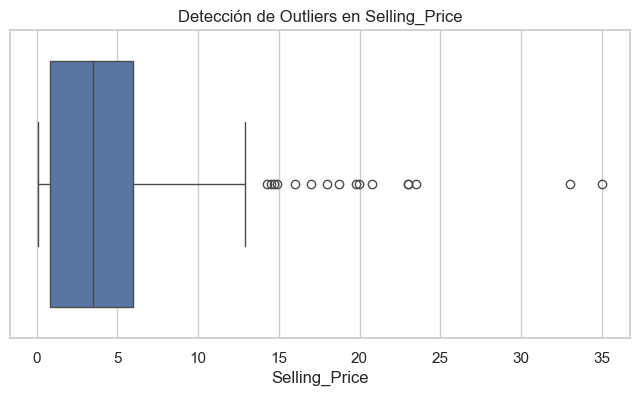

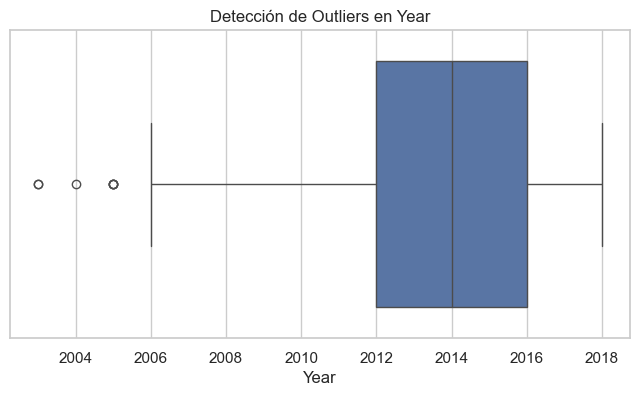

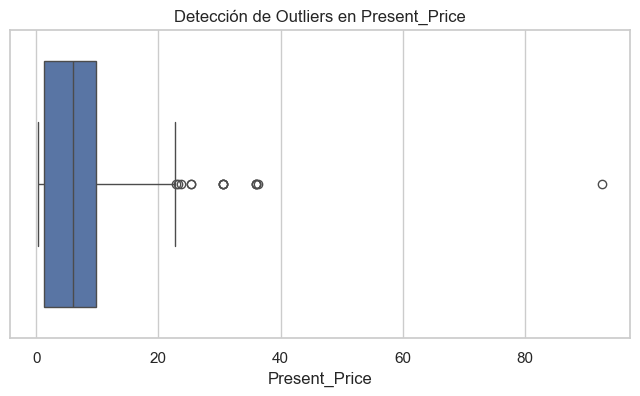

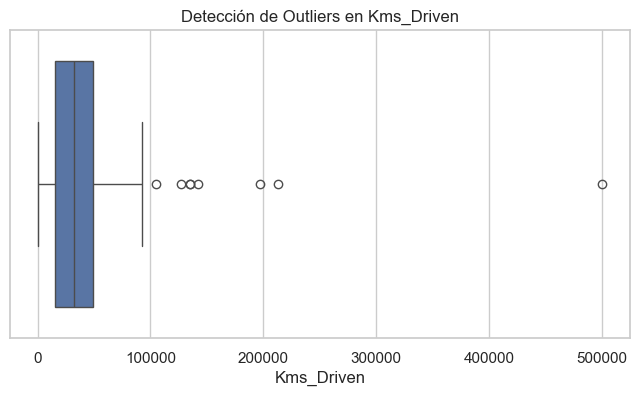

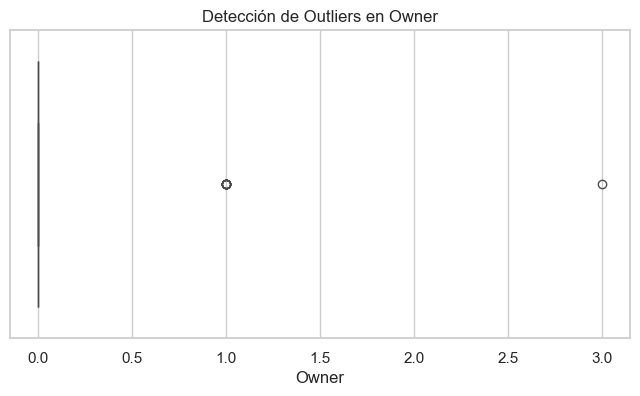

In [46]:
#Valores atípicos para variables numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Valores atípicos aproximados:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")
print("\n")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Selling_Price'])
plt.title('Detección de Outliers en Selling_Price')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Year'])
plt.title('Detección de Outliers en Year')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Present_Price'])
plt.title('Detección de Outliers en Present_Price')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Kms_Driven'])
plt.title('Detección de Outliers en Kms_Driven')
plt.show()


plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Owner'])
plt.title('Detección de Outliers en Owner')
plt.show()

Esto se debe a que hay coches muy antiguos, con muchos kilómetros o precios muy altos/bajos.

In [47]:
#Detección de valores negativos donde no deberían existir
print("Valores negativos donde no deberían existir:")
for col in ['Kms_Driven', 'Selling_Price', 'Present_Price']:
    negativos = df[df[col] < 0]
    print(f"{col}: {len(negativos)} valores negativos")
print("\n")

Valores negativos donde no deberían existir:
Kms_Driven: 0 valores negativos
Selling_Price: 0 valores negativos
Present_Price: 0 valores negativos




In [42]:
# Consistencia de categorías
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Valores únicos por columna categórica:")
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Valores únicos por columna categórica:
Car_Name: ['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Drea

# **3. Mapa de correlación para identificar relaciones entre variables numéricas y la variable objetivo**

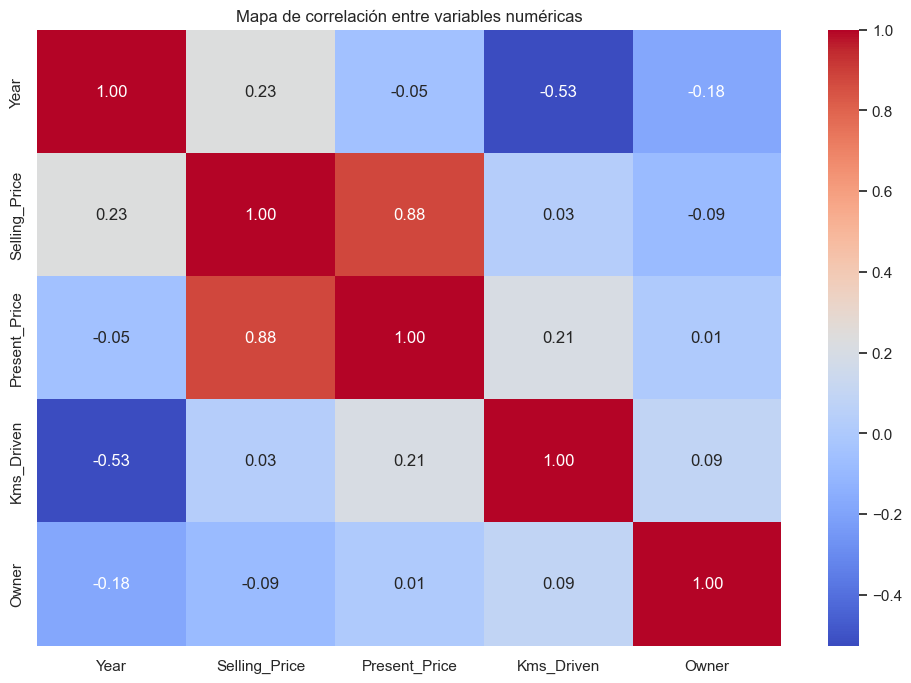

In [43]:
# --- Análisis de correlación ---
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de correlación entre variables numéricas")
plt.show()

El mapa de calor muestra la relación numérica entre las variables del dataset. Los valores cercanos a 1 o -1 indican relaciones fuertes (positivas o negativas), mientras que los valores cercanos a 0 indican relaciones débiles o inexistentes.  

Selling_Price y Present_Price (0.88): Es el predictor más fuerte para el precio de venta.

Selling_Price y Year (0.23): Existe una correlación positiva. 

Fuel_Type, Seller_Type, Transmission, y Owner también pueden aportar información adicional al modelo.